In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("..//data//anthropometric_2003_2023.csv")
df.head(3)

,Year,Gender,Age,1.Body Weight (kg),2.Stature height (cm),3.The height of the root of the nose in standing (cm),4.Height of shoulders in standing position (cm),5.Height of the elbow in standing position (cm),6.The height of the tip of the 3rd finger in standing position (cm),7.Arm's reach in standing position (cm),...,16.Knee height in sitting position (cm),17.Arm's reach in sitting position (cm),18.The length of the forearm and hand at the elbow bend (cm),19.Thigh length in sitting position at knee bend (cm),20.Leg length when sitting forward (cm),21.Arm's reach in sitting position (cm),22.Palm width (cm),23.Palm length (cm),24.Foot width (cm),25.Foot lenght (cm)
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2003.0,M,18,65,"173,5","168,0","144,0","105,0","67,0","220,0",...,"54,0","134,0","48,0","60,0","102,0","88,0","11,0","19,0","10,0","25,0"
2,2003.0,M,18,73,"170,0","168,0","152,0","118,0","71,0","224,0",...,"55,0","138,0","50,0","54,0","106,0","74,0","8,0","19,0","11,0","22,0"


In [2]:
# --- Limpieza de datos

# Eliminar columnas
def drop_columns(data: pd.DataFrame, column_names: list) -> pd.DataFrame:
    return data[column_names]

# Eliminar nulos
def drop_nulls(data: pd.DataFrame) -> pd.DataFrame:
    return data.dropna()

# Resumen
def check_quality(data: pd.DataFrame):

    """Basic Quality Check. Returns DataFrame with columns, types 
    and unique, missing and duplicate elements plus their ratios.
    Complement/extension of .info() function."""

    n = len(data)

    summary = []
    for column in data:
        col_type = type(data[column].iloc[0])
        elements = data[column].count()
        unique = data[column].nunique(dropna = True)
        rate_unique = round(unique / n * 100, 2)
        missing = data[column].isna().sum() 
        rate_missing = round(missing / n * 100, 2)
        duplicated = data[column].duplicated().sum()
        
        summary.append((column, col_type, elements, unique, rate_unique, missing, rate_missing, duplicated))
    
    return pd.DataFrame(summary, columns = ['column', 'type', 'elements', 'unique', 'rate_unique', 'missing', 'rate_missing', 'duplicated'])


# Cambiar type
def change_type(data: pd.DataFrame, change_dict: dict) -> pd.DataFrame:

    """Changes column types to correct type indicated on dictionary values."""

    for column, correct_type in change_dict.items():
        
        if column not in data.columns:
            raise ValueError(f"Column {column} does not exist.")
        
        data[column] = data[column].astype(correct_type)

    return data
    

In [ ]:
df_red = drop_columns(df, ['Year', 'Gender', 'Age', '1.Body Weight (kg)', '2.Stature height (cm)',
                           '3.The height of the root of the nose in standing (cm)', '4.Height of shoulders in standing position (cm)',
                           '5.Height of the elbow in standing position (cm)', '6.The height of the tip of the 3rd finger in standing position (cm)',
                           '8.The width of the shoulders (cm)', "10.Arm's reach in standing position (cm)", '16.Knee height in sitting position (cm)',
                           '18.The length of the forearm and hand at the elbow bend  (cm)', '20.Leg length when sitting forward (cm)',
                           '22.Palm width (cm)', '23.Palm length (cm)', '24.Foot width (cm)', '25.Foot lenght (cm)'])

df_red = drop_nulls(df_red)

df_red.columns = ['year', 'gender', 'age', 'weight', 'height', 'eye_height', 'shoulder_height', 'elbow_height', 'fingertip_height', 'shoulder_width', 'arms_reach', 'knee_height', 'fingertip_to_elbow_length', 'leg_length', 'palm_width', 'palm_length', 'foot_width', 'foot_length']

check_quality(df_red)

change_dict = {}
for column in df_red.columns:
    if column != 'gender':
        change_dict[column] = 'float'
    else:
        change_dict[column] = 'str'
change_type

,column,type,elements,unique,rate_unique,missing,rate_missing,duplicated
0,year,<class 'numpy.float64'>,4321,21,0.49,0,0.0,4300
1,gender,<class 'str'>,4321,2,0.05,0,0.0,4319
2,age,<class 'str'>,4321,98,2.27,0,0.0,4223
3,weight,<class 'str'>,4321,313,7.24,0,0.0,4008
4,height,<class 'str'>,4321,216,5.00,0,0.0,4105
5,eye_height,<class 'str'>,4321,227,5.25,0,0.0,4094
6,shoulder_height,<class 'str'>,4321,228,5.28,0,0.0,4093
7,elbow_height,<class 'str'>,4321,219,5.07,0,0.0,4102
8,fingertip_height,<class 'str'>,4321,213,4.93,0,0.0,4108
9,shoulder_width,<class 'str'>,4321,177,4.10,0,0.0,4144


1.7323088415366241
[1.05712523 2.66335346 2.05361628 1.68191067 0.44794249 0.44787525
 0.17492434 2.4276824  1.68875885 1.98692955 0.07038627 2.7168658
 2.3336419  0.60494975 0.51988402 0.52428738 0.86115249 1.4758904
 1.2171556  0.82487524 1.71869336 0.40187557 0.82742745 1.03432626
 1.28440992 2.20187433 0.56964201 1.44655774 1.66450421 0.14249392
 1.70668362 0.48838012 0.19434932 2.65825531 2.70494032 2.26660969
 0.86218821 0.2852871  1.9204709  1.24003597 0.35321369 1.39343016
 0.10886841 2.5479577  0.73441518 1.85994683 0.88197371 1.46282029
 1.53709218 0.52832946 2.71595915 2.17387659 2.63208785 2.50755473
 1.67979615 2.58295462 0.25969666 0.55935265 0.13908416 0.91994075
 1.09653609 0.76945452 2.32331293 1.00754014 0.79617641 1.52590162
 0.40586307 2.24932463 0.22083027 2.76419362 2.16582543 0.56697106
 0.02839616 2.28630257 1.98354179 2.04528991 2.16310898 0.2194197
 1.01231388 0.33601559 2.41911643 1.75059978 0.93546208 0.19018653
 0.87994213 0.91953093 2.0469598  1.79035123 2

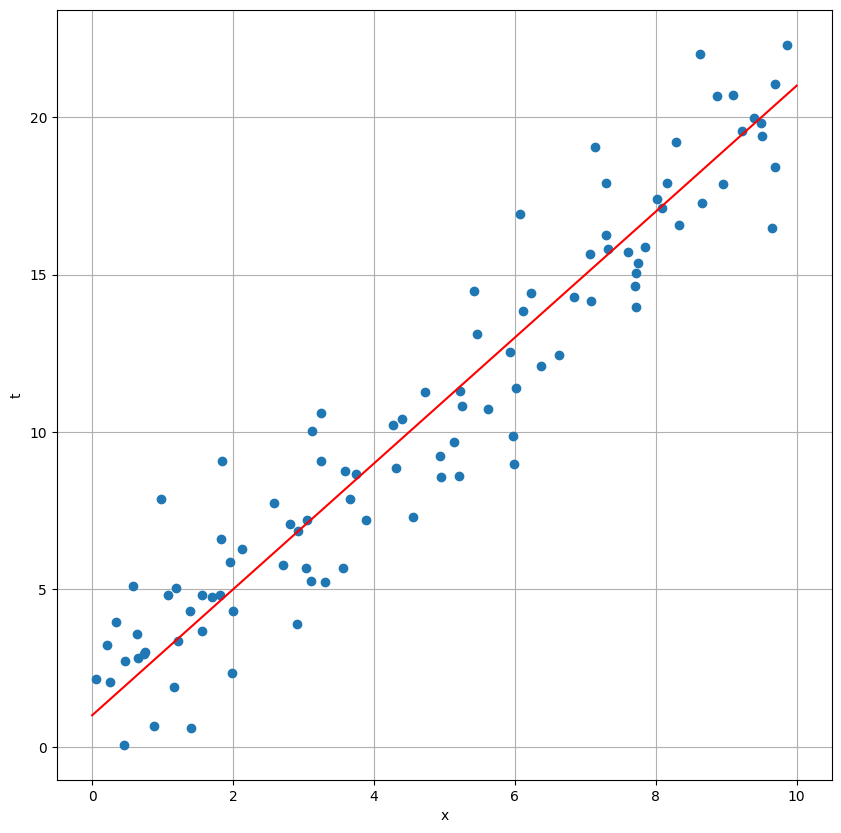

In [ ]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np




# Parameters:
a = 2.0
b = 1.0
xmin = 0.0
xmax = 10.0
noise = 2.0
n = 100

# Randomly generated problem data:
np.random.seed(42)
x = xmin + np.random.rand(n)*(xmax - xmin)
t = a*x + b + np.random.randn(n)*noise

    
def regresion_lineal_simple(x, t, num_iters=8, eta=0.01):
        w = np.random.randn()
        b = np.random.randn()

        xmin, xmax = x.min(), x.max()

        n = len(x)

        for i in range(num_iters):

            # Definición de la recta
            y = b + w * x 

            #Cálculo del error
            e = y - t
            mse = sum(t - y)**2 / n

            #Cálculo del gradiente de los pesos b, w1
            db = 2 * sum(y - t) / n
            dg = 2 * sum(y - t) * x / n

            #Actualización de parametros
            b = b - eta * db
            w = w - eta * dg
            
            plt.plot(x, t, 'o', label='Datos reales')
            plt.plot([xmin, xmax], [w * xmin + b, w * xmax + b], 'grey', label=f'Modelo (ite {i + 1})')
        plt.plot([xmin, xmax], [w * xmin + b, w * xmax + b], 'r-', label='Modelo final')
        plt.grid(True)
        plt.xlabel("x")
        plt.ylabel("t")
        plt.show()

        return w, b

def show_data():

    plt.figure(figsize=(10, 10))
    plt.plot(x, t, 'o')
    plt.plot([xmin, xmax], [a*xmin + b, a*xmax + b], 'r-')
    plt.grid(True)
    plt.xlabel("x")
    plt.ylabel("t")
    plt.show()

def main():
    regresion_lineal_simple(x = x, t = t)
    show_data()


main()